# Trigonometric Functions — Lecture 1
## Introduction · Basics of Angle and Trigonometry

**Source:** [Trigonometric Functions 01 | Introduction | Basics of Angle and Trigonometry](https://www.youtube.com/watch?v=anqu3ul9WiI&list=PLF_7kfnwLFCGWE2w0BsarSM9mbBJMrdRL), Physics Wallah (Class 11 / IIT JEE), about 55 min

### What this lecture covers
1. Trigonometry vs. trigonometric *functions*, and what "plane" trigonometry means
2. Definition of an angle: $\theta = \dfrac{\ell}{r}$, initial and terminal lines
3. Sign of an angle (anticlockwise is positive, clockwise is negative)
4. How big an angle can be: $\theta \in (-\infty, \infty)$
5. Systems of measurement: **degree** and **radian**, with $180^\circ = \pi$ rad
6. Sub-units: minutes and seconds; revolutions
7. Solved examples
8. Revision of Class 10 trigonometric ratios and why there are exactly six
9. The three basic Pythagorean identities, with proof
10. Three "advanced" identities (product = sum / difference), with proofs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyArrowPatch, Polygon
from fractions import Fraction

# Consistent look for every figure in these notes
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def clean(ax, lim=1.4):
    # Square, axis-free canvas for geometric diagrams
    ax.set_aspect("equal"); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.axis("off")

def ray(ax, ang_deg, r=1.2, color=INK, lw=2, label=None):
    a = np.deg2rad(ang_deg)
    ax.plot([0, r*np.cos(a)], [0, r*np.sin(a)], color=color, lw=lw, solid_capstyle="round")
    if label:
        ax.text(1.08*r*np.cos(a), 1.08*r*np.sin(a), label, color=INK2, ha="center", va="center", fontsize=9)

def sweep(ax, start_deg, end_deg, r0=0.35, color=BLUE, turns_gap=0.06):
    # Arrowed sweep from start to end; spirals outward when |angle| > 360°
    t = np.linspace(np.deg2rad(start_deg), np.deg2rad(end_deg), 400)
    rr = r0 + turns_gap*np.abs(t - t[0])/(2*np.pi)
    ax.plot(rr*np.cos(t), rr*np.sin(t), color=color, lw=2)
    ax.add_patch(FancyArrowPatch((rr[-6]*np.cos(t[-6]), rr[-6]*np.sin(t[-6])),
                                 (rr[-1]*np.cos(t[-1]), rr[-1]*np.sin(t[-1])),
                                 arrowstyle="-|>", mutation_scale=14, color=color, lw=0))

def deg_to_rad_str(d):
    f = Fraction(d, 180)
    if f == 0: return "0"
    num = "" if abs(f.numerator) == 1 else str(abs(f.numerator))
    s = ("-" if f < 0 else "") + num + "π"
    return s if f.denominator == 1 else f"{s}/{f.denominator}"
print("ready")

ready


---
## 1. Trigonometry vs. Trigonometric Functions

| Class 10: *Trigonometry* | Class 11: *Trigonometric Functions* |
|---|---|
| $\sin\theta, \cos\theta, \tan\theta, \dots$ are treated as **ratios** of sides of a right triangle | The same quantities are treated as **functions** of an angle that can be any real number |
| Angles are limited to $0^\circ$–$90^\circ$ | Angles can be negative, larger than $360^\circ$, anything in $(-\infty, \infty)$ |

- The chapter is also called **plane trigonometry** because it deals with **plane angles**, meaning angles formed in a plane. There are other kinds, such as *solid angles*, but they are not part of this chapter.
- Trigonometry is several hundred years old. **Indian mathematicians** contributed a great deal to its development and were among the first to know and use trigonometric functions.

---
## 2. What is an Angle?

### 2.1 Definition using a circle
Take a circle of radius $r$ and an arc of length $\ell$ on it. The angle $\theta$ that the arc **subtends at the centre** is

$$\boxed{\theta = \frac{\ell}{r}} \qquad (\theta \text{ in radians})$$

- $\ell$ and $r$ must be in the **same unit**, so the units cancel. That makes the radian dimensionless.
- The **radian** is the **SI unit** of angle.
- **1 radian** is the angle subtended by an arc whose length equals the radius ($\ell = r$).

### 2.2 Initial and terminal lines
An angle is formed by **rotating** a ray:
- **Initial line**: the starting position of the ray
- **Terminal line**: the final position after rotation

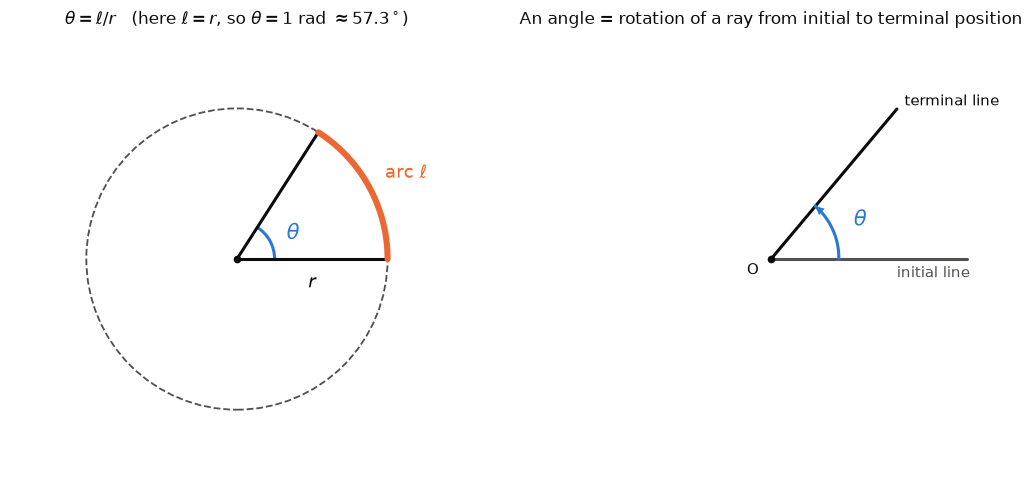

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))

# (a) theta = l / r
ax = axes[0]; clean(ax, 1.5)
ax.add_patch(Circle((0, 0), 1, fill=False, ec=INK2, lw=1.2, ls="--"))
th = 1.0                                     # 1 rad, so the arc equals the radius
ray(ax, 0, 1, INK, label=None); ray(ax, np.rad2deg(th), 1, INK)
t = np.linspace(0, th, 100)
ax.plot(np.cos(t), np.sin(t), color=ORANGE, lw=4, solid_capstyle="round")
ax.add_patch(Arc((0, 0), 0.5, 0.5, theta1=0, theta2=np.rad2deg(th), color=BLUE, lw=2))
ax.text(0.33, 0.13, r"$\theta$", color=BLUE, fontsize=14)
ax.text(1.12*np.cos(th/2), 1.12*np.sin(th/2), r"arc $\ell$", color=ORANGE, fontsize=12)
ax.text(0.5, -0.1, r"$r$", fontsize=12, ha="center", va="top")
ax.plot(0, 0, "o", color=INK, ms=4)
ax.set_title(r"$\theta = \ell / r$   (here $\ell = r$, so $\theta = 1$ rad $\approx 57.3^\circ$)", fontsize=11)

# (b) initial and terminal line
ax = axes[1]; clean(ax, 1.5)
ray(ax, 0, 1.3, INK2, label=""); ray(ax, 50, 1.3, INK, label="")
ax.text(1.32, -0.12, "initial line", color=INK2, ha="right", fontsize=10)
ax.text(1.3*np.cos(np.deg2rad(50))+0.05, 1.3*np.sin(np.deg2rad(50)), "terminal line", fontsize=10, va="bottom")
sweep(ax, 0, 50, r0=0.45)
ax.text(0.55, 0.22, r"$\theta$", color=BLUE, fontsize=14)
ax.plot(0, 0, "o", color=INK, ms=4); ax.text(-0.08, -0.1, "O", ha="right")
ax.set_title("An angle = rotation of a ray from initial to terminal position", fontsize=11)
plt.tight_layout(); plt.show()

**Example (from the lecture).** In a circle of radius $r = 4$ m, an arc of length $\ell = 2$ m subtends

$$\theta = \frac{\ell}{r} = \frac{2\text{ m}}{4\text{ m}} = \frac{1}{2}\ \text{radian}.$$

In [3]:
l, r = 2, 4
theta = l / r
print(f"theta = {theta} rad = {np.rad2deg(theta):.4f} degrees")

theta = 0.5 rad = 28.6479 degrees


---
## 3. Sign of an Angle

| Direction of rotation (initial to terminal) | Name | Sign |
|---|---|---|
| **Anticlockwise** (also called *counter-clockwise*) | anticlockwise sense | **Positive** $(+\theta)$ |
| **Clockwise** | clockwise sense | **Negative** $(-\theta)$ |

The *same* pair of lines can describe a positive or a negative angle. It depends on **how the angle was traced**.

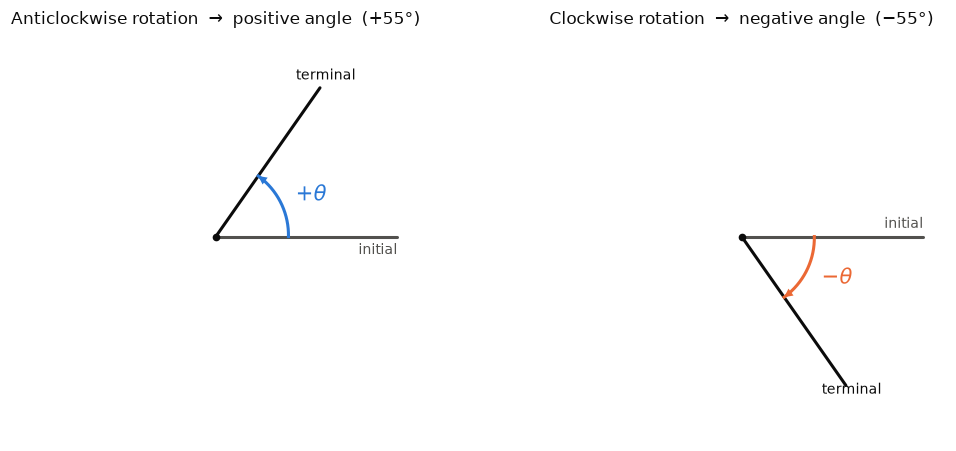

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, end, col, title in [(axes[0], 55, BLUE, "Anticlockwise rotation  →  positive angle  (+55°)"),
                            (axes[1], -55, ORANGE, "Clockwise rotation  →  negative angle  (−55°)")]:
    clean(ax, 1.4)
    ray(ax, 0, 1.25, INK2); ray(ax, end, 1.25, INK)
    sweep(ax, 0, end, r0=0.5, color=col)
    ax.text(1.25, 0.06 if end < 0 else -0.12, "initial", color=INK2, ha="right", fontsize=9)
    ax.text(1.32*np.cos(np.deg2rad(end)), 1.32*np.sin(np.deg2rad(end)), "terminal", fontsize=9, ha="center")
    ax.text(0.62*np.cos(np.deg2rad(end/2)), 0.62*np.sin(np.deg2rad(end/2)),
            r"$+\theta$" if end > 0 else r"$-\theta$", color=col, fontsize=14, ha="left", va="center")
    ax.plot(0, 0, "o", color=INK, ms=4)
    ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()

---
## 4. How Large (or Small) Can an Angle Be?

In Class 10 we only met angles up to $90^\circ$. Now the ray can keep rotating:

- **Zero angle:** terminal line lies on the initial line with no rotation, so $\theta = 0^\circ = 0$ rad.
- **Greater than $90^\circ$** (obtuse), **greater than $180^\circ$** (reflex): just keep rotating.
- **Exactly $360^\circ$:** one full revolution brings the ray back onto the initial line.
  - Geometrically $0^\circ$ and $360^\circ$ end in the **same position**, which is why later we will find $\sin 360^\circ = \sin 0^\circ$ (and likewise for every ratio).
- **Greater than $360^\circ$:** keep rotating after one full turn: $360^\circ, 720^\circ, \dots$
- Rotate anticlockwise forever and the angle tends to $+\infty$. Rotate clockwise forever and it tends to $-\infty$.

$$\boxed{\theta \in (-\infty,\ \infty)} \quad\text{An angle can be any real number.}$$

This fact is used throughout the chapter. It is what makes $\sin, \cos, \dots$ functions on all of $\mathbb{R}$.

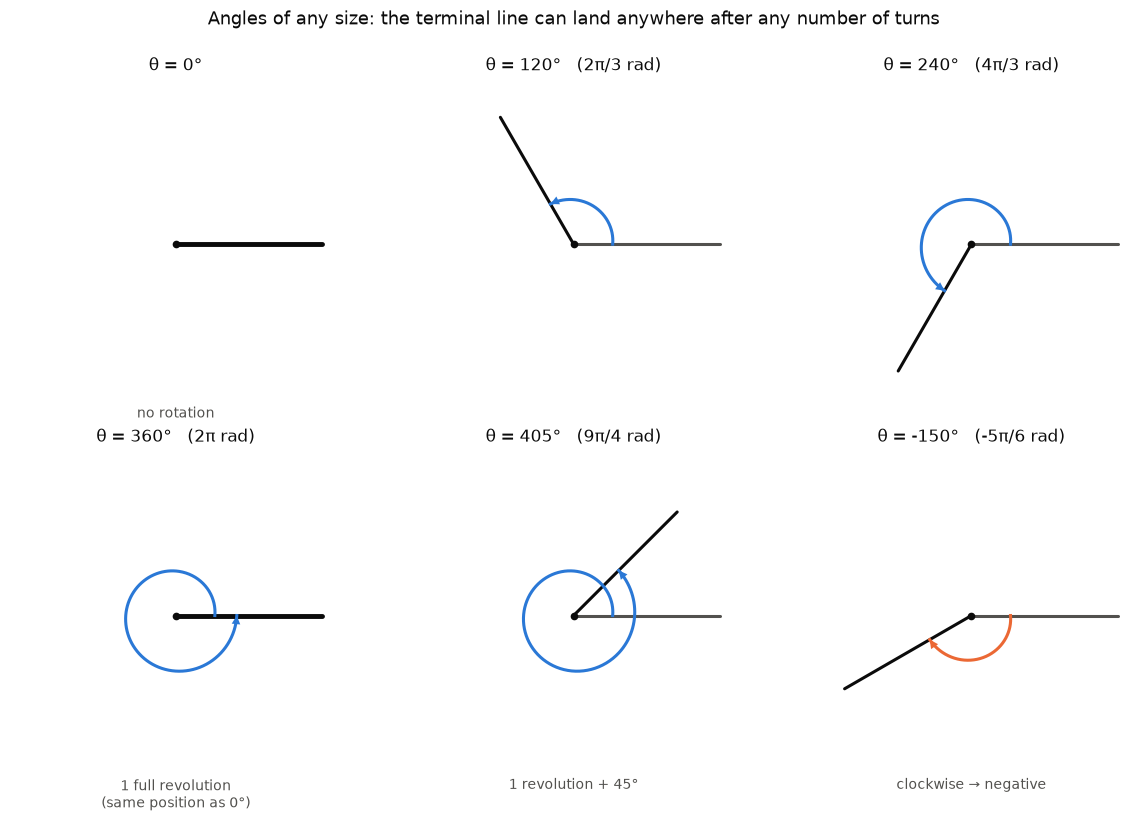

In [5]:
angles = [0, 120, 240, 360, 405, -150]
fig, axes = plt.subplots(2, 3, figsize=(11, 7.4))
for ax, a in zip(axes.flat, angles):
    clean(ax, 1.35)
    ray(ax, 0, 1.2, INK2)
    ray(ax, a, 1.2, INK, lw=2 if a % 360 else 3.2)
    if a != 0:
        sweep(ax, 0, a, r0=0.32, color=BLUE if a > 0 else ORANGE, turns_gap=0.18)
    ax.plot(0, 0, "o", color=INK, ms=4)
    note = {0: "no rotation", 360: "1 full revolution\n(same position as 0°)",
            405: "1 revolution + 45°", -150: "clockwise → negative"}.get(a, "")
    ax.set_title(f"θ = {a}°   ({deg_to_rad_str(a)} rad)" if a else "θ = 0°", fontsize=11)
    ax.text(0, -1.33, note, ha="center", va="top", color=INK2, fontsize=9)
fig.suptitle("Angles of any size: the terminal line can land anywhere after any number of turns",
             fontsize=12, y=1.0)
plt.tight_layout(); plt.show()

---
## 5. Systems of Measuring Angles

Like length (m, km, cm, miles), angle has several units. Two are in the syllabus:

1. **Degree measure** (sexagesimal system), the one we have used since childhood
2. **Radian measure** (circular system), the SI unit and the one **examiners prefer** in Class 11 and 12

(There is also a *grade* system, which is not in the syllabus.)

### 5.1 The key relation
A **straight angle** (the initial and terminal lines are opposite) is $180^\circ$ in degree measure and $\pi$ in radian measure. Both describe the same angle, so

$$\boxed{180^\circ = \pi \text{ radians}}$$

From this one relation:

$$1^\circ = \frac{\pi}{180}\ \text{rad} \approx 0.01745 \text{ rad}, \qquad 1\ \text{rad} = \frac{180^\circ}{\pi} \approx 57.296^\circ$$

- **Degree to radian:** multiply by $\dfrac{\pi}{180}$
- **Radian to degree:** multiply by $\dfrac{180}{\pi}$

### 5.2 Notation (important)
- $\pi^c$: a small **c** on top means radians.
- $30^\circ$: the degree symbol means degrees.
- **No symbol at all** (e.g. $\pi$, $\tfrac{\pi}{2}$, $2$) means **radians by default**, because it is the SI unit. Writing $\sin 2$ means the sine of 2 *radians*, not 2 degrees.

In [6]:
print(f"{'Degrees':>8} | {'Radians':>8} | {'≈ decimal':>9}")
print("-" * 32)
for d in [0, 30, 45, 60, 90, 120, 135, 150, 180, 270, 360]:
    print(f"{d:>7}° | {deg_to_rad_str(d):>8} | {np.deg2rad(d):9.4f}")

 Degrees |  Radians | ≈ decimal
--------------------------------
      0° |        0 |    0.0000
     30° |      π/6 |    0.5236
     45° |      π/4 |    0.7854
     60° |      π/3 |    1.0472
     90° |      π/2 |    1.5708
    120° |     2π/3 |    2.0944
    135° |     3π/4 |    2.3562
    150° |     5π/6 |    2.6180
    180° |        π |    3.1416
    270° |     3π/2 |    4.7124
    360° |       2π |    6.2832


The standard angles $0^\circ, 30^\circ, 45^\circ, 60^\circ, 90^\circ$ (and $180^\circ, 270^\circ, 360^\circ$) should be memorised in **both** units, so you can switch between them on sight. The unit circle below shows both labels.

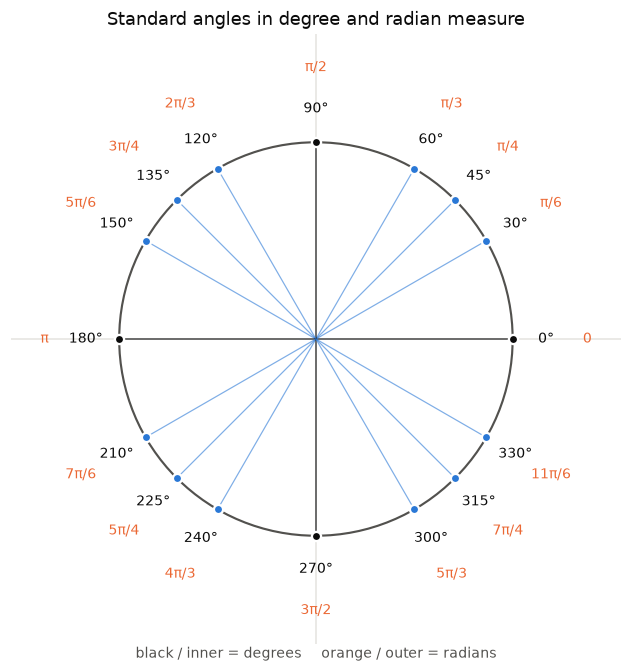

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 7.2)); clean(ax, 1.55)
ax.add_patch(Circle((0, 0), 1, fill=False, ec=INK2, lw=1.4))
ax.axhline(0, color=GRID, lw=1, zorder=0); ax.axvline(0, color=GRID, lw=1, zorder=0)
std = [0, 30, 45, 60, 90, 120, 135, 150, 180, 210, 225, 240, 270, 300, 315, 330]
for d in std:
    a = np.deg2rad(d); c, s = np.cos(a), np.sin(a)
    key = d % 90 == 0
    ax.plot([0, c], [0, s], color=BLUE if not key else INK, lw=0.8 if not key else 1.2, alpha=0.6)
    ax.plot(c, s, "o", color=BLUE if not key else INK, ms=6, mec="white", mew=1.5, zorder=3)
    ax.text(1.17*c, 1.17*s, f"{d}°", ha="center", va="center", fontsize=9, color=INK)
    ax.text(1.38*c, 1.38*s, deg_to_rad_str(d), ha="center", va="center", fontsize=9, color=ORANGE)
ax.text(0, -1.62, "black / inner = degrees     orange / outer = radians", ha="center", color=INK2, fontsize=9)
ax.set_title("Standard angles in degree and radian measure", fontsize=12)
plt.show()

### 5.3 Converting standard angles (as done in class)
All of these come straight from $180^\circ = \pi$:

| Operation on $180^\circ = \pi$ | Result |
|---|---|
| $\div 2$ | $90^\circ = \dfrac{\pi}{2}$ |
| $\div 3$ | $60^\circ = \dfrac{\pi}{3}$ |
| $\div 4$ | $45^\circ = \dfrac{\pi}{4}$ |
| $\div 6$ | $30^\circ = \dfrac{\pi}{6}$ |
| $\times 2$ | $360^\circ = 2\pi$ |
| $\times \tfrac{3}{2}$ | $270^\circ = \dfrac{3\pi}{2}$ |
| — | $0^\circ = 0$ rad |

---
## 6. Minutes, Seconds and Revolutions

### 6.1 Sub-units of a degree
Just as time is divided into minutes and seconds, so is a degree:

$$1^\circ = 60' \ (\text{minutes}), \qquad 1' = 60'' \ (\text{seconds}), \qquad 1^\circ = 3600''$$

So a mixed angle such as $40^\circ 30'$ means $40^\circ + 30'$.

**Strategy for mixed angles:** first convert everything to **degrees**, then convert degrees to radians.

### 6.2 Revolutions
One complete rotation of the ray back to the initial line is **one revolution**:

$$1 \text{ revolution} = 360^\circ = 2\pi \text{ rad}$$

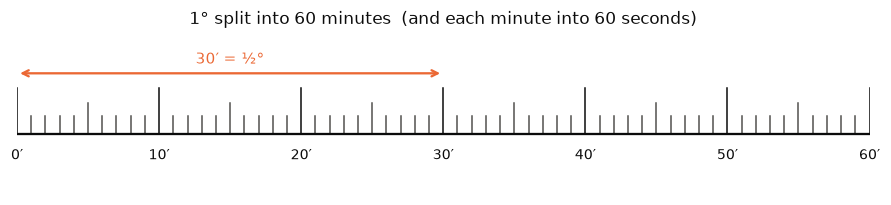

In [8]:
fig, ax = plt.subplots(figsize=(10, 1.9))
ax.set_xlim(0, 60); ax.set_ylim(-1.2, 2.0); ax.axis("off")
for m in range(61):
    h = 0.9 if m % 10 == 0 else (0.6 if m % 5 == 0 else 0.35)
    ax.plot([m, m], [0, h], color=INK if m % 10 == 0 else INK2, lw=1)
    if m % 10 == 0: ax.text(m, -0.3, f"{m}′", ha="center", va="top", fontsize=9)
ax.plot([0, 60], [0, 0], color=INK, lw=1.5)
ax.annotate("", xy=(30, 1.2), xytext=(0, 1.2), arrowprops=dict(arrowstyle="<->", color=ORANGE, lw=1.5))
ax.text(15, 1.32, "30′ = ½°", color=ORANGE, ha="center", va="bottom")
ax.set_title("1° split into 60 minutes  (and each minute into 60 seconds)", fontsize=11)
plt.show()

### Worked example: convert $40^\circ 30'$ to radians
$$40^\circ 30' = 40^\circ + \left(\tfrac{30}{60}\right)^\circ = 40\tfrac{1}{2}^\circ = \left(\tfrac{81}{2}\right)^\circ$$

$$\left(\tfrac{81}{2}\right)^\circ = \frac{81}{2}\times\frac{\pi}{180}\ \text{rad} = \frac{81\pi}{360}\ \text{rad} = \frac{9\pi}{40}\ \text{rad}$$

In [9]:
def dms_to_rad(deg, minutes=0, seconds=0):
    # Degrees–minutes–seconds → radians: first collapse to pure degrees
    total_deg = deg + minutes/60 + seconds/3600
    return total_deg, total_deg * np.pi / 180

d, r = dms_to_rad(40, 30)
print(f"40°30' = {d}° = {r:.6f} rad")
print(f"81π/360 = {81*np.pi/360:.6f} rad   ✓")

40°30' = 40.5° = 0.706858 rad
81π/360 = 0.706858 rad   ✓


---
## 7. Solved Questions

### Q1. Equal arcs in two circles
> Arcs of the **same length** in two circles subtend angles of $60^\circ$ and $75^\circ$ at their centres. Find the ratio of their radii.

Let the radii be $r$ (60° circle) and $R$ (75° circle), with common arc length $\ell$.

**Remember: in $\ell = r\theta$, $\theta$ must be in radians.** Never plug degrees into this formula.

$$60^\circ = \frac{\pi}{3}, \qquad 75^\circ = 75\times\frac{\pi}{180} = \frac{5\pi}{12}$$

$$\ell = r\cdot\frac{\pi}{3} \quad (1), \qquad \ell = R\cdot\frac{5\pi}{12} \quad (2)$$

Dividing (1) by (2):
$$1 = \frac{r}{R}\cdot\frac{\pi/3}{5\pi/12} = \frac{r}{R}\cdot\frac{4}{5} \;\Longrightarrow\; \boxed{\frac{r}{R} = \frac{5}{4}, \text{ i.e. } r : R = 5 : 4}$$

This makes sense: the **smaller** angle needs the **larger** circle to cover the same arc length.

r / R = 1.2500  (expected 5/4 = 1.25)


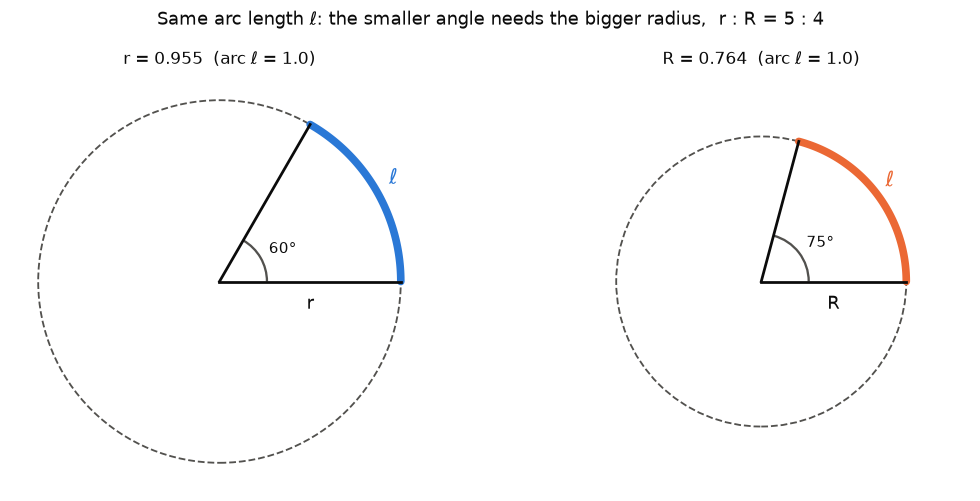

In [10]:
l = 1.0
r = l / np.deg2rad(60); R = l / np.deg2rad(75)
print(f"r / R = {r/R:.4f}  (expected 5/4 = {5/4})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
for ax, deg, rad_, col, name in [(axes[0], 60, r, BLUE, "r"), (axes[1], 75, R, ORANGE, "R")]:
    ax.set_aspect("equal"); ax.axis("off"); lim = 1.15*r; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.add_patch(Circle((0, 0), rad_, fill=False, ec=INK2, ls="--", lw=1.2))
    a = np.deg2rad(deg); t = np.linspace(0, a, 100)
    ax.plot(rad_*np.cos(t), rad_*np.sin(t), color=col, lw=5, solid_capstyle="round")
    ax.plot([0, rad_], [0, 0], color=INK, lw=1.8); ax.plot([0, rad_*np.cos(a)], [0, rad_*np.sin(a)], color=INK, lw=1.8)
    ax.add_patch(Arc((0, 0), 0.5, 0.5, theta1=0, theta2=deg, color=INK2, lw=1.5))
    ax.text(0.3*np.cos(a/2), 0.3*np.sin(a/2), f"{deg}°", fontsize=10)
    ax.text(rad_/2, -0.07, name, ha="center", va="top", fontsize=12)
    ax.text(1.08*rad_*np.cos(a/2), 1.08*rad_*np.sin(a/2), "ℓ", color=col, fontsize=14)
    ax.set_title(f"{name} = {rad_:.3f}  (arc ℓ = {l})", fontsize=11)
fig.suptitle("Same arc length ℓ: the smaller angle needs the bigger radius,  r : R = 5 : 4", fontsize=12)
plt.tight_layout(); plt.show()

### Q2. Convert $40^\circ 20'$ to radians
$$40^\circ 20' = 40^\circ + \left(\tfrac{20}{60}\right)^\circ = \left(40 + \tfrac{1}{3}\right)^\circ = \left(\tfrac{121}{3}\right)^\circ$$

$$\left(\tfrac{121}{3}\right)^\circ = \frac{121}{3}\times\frac{\pi}{180} = \boxed{\frac{121\pi}{540}\ \text{rad}}$$

In [11]:
d, rad_ = dms_to_rad(40, 20)
print(f"40°20' = {d:.6f}° = {rad_:.6f} rad;   121π/540 = {121*np.pi/540:.6f}  ✓")

40°20' = 40.333333° = 0.703949 rad;   121π/540 = 0.703949  ✓


---
## 8. Trigonometric Ratios (Class 10 revision)

Trigonometry is usually set up in a **right-angled triangle**. For a triangle that is not right-angled, drop a perpendicular to create right triangles.

For an acute angle $\theta$ in a right triangle:
- **Perpendicular $P$**: the side **opposite** $\theta$
- **Base $B$**: the side **adjacent** to $\theta$ (not the hypotenuse)
- **Hypotenuse $H$**: the side opposite the right angle, and the longest side

**Pythagoras theorem:** $\;P^2 + B^2 = H^2$

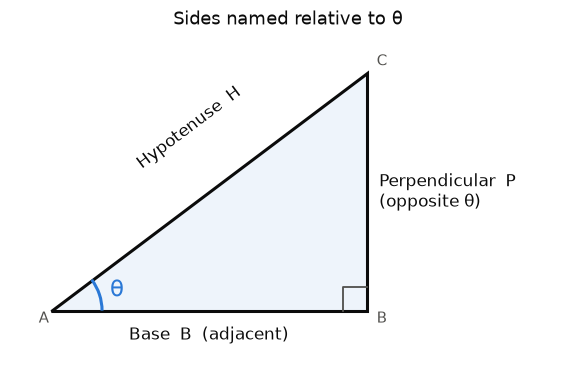

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.2)); ax.set_aspect("equal"); ax.axis("off")
A, Bp, C = np.array([0, 0]), np.array([4, 0]), np.array([4, 3])   # angle θ at A, right angle at B
ax.add_patch(Polygon([A, Bp, C], closed=True, fill=True, fc="#2a78d614", ec=INK, lw=2))
ax.plot([3.7, 3.7, 4], [0, 0.3, 0.3], color=INK2, lw=1.2)                      # right-angle mark
ax.add_patch(Arc(A, 1.3, 1.3, theta1=0, theta2=np.rad2deg(np.arctan2(3, 4)), color=BLUE, lw=2))
ax.text(0.75, 0.18, "θ", color=BLUE, fontsize=15)
ax.text(2, -0.2, "Base  B  (adjacent)", ha="center", va="top", fontsize=11)
ax.text(4.15, 1.5, "Perpendicular  P\n(opposite θ)", ha="left", va="center", fontsize=11)
ax.text(1.75, 1.75, "Hypotenuse  H", ha="center", va="bottom", fontsize=11, rotation=36.87)
for p, n in [(A, "A"), (Bp, "B"), (C, "C")]:
    ax.text(*(p + np.array([-0.15 if n == "A" else 0.12, -0.15 if n != "C" else 0.1])), n, color=INK2)
ax.set_xlim(-0.5, 6.5); ax.set_ylim(-0.8, 3.5)
ax.set_title("Sides named relative to θ", fontsize=12)
plt.show()

### 8.1 The six ratios

| Ratio | Definition | Reciprocal of |
|---|---|---|
| $\sin\theta$ | $\dfrac{P}{H}$ | $\csc\theta$ |
| $\cos\theta$ | $\dfrac{B}{H}$ | $\sec\theta$ |
| $\tan\theta$ | $\dfrac{P}{B}$ | $\cot\theta$ |
| $\csc\theta$ (cosec) | $\dfrac{H}{P}$ | $\sin\theta$ |
| $\sec\theta$ | $\dfrac{H}{B}$ | $\cos\theta$ |
| $\cot\theta$ | $\dfrac{B}{P}$ | $\tan\theta$ |

**Reciprocal pairs:**
$$\csc\theta = \frac{1}{\sin\theta}, \qquad \sec\theta = \frac{1}{\cos\theta}, \qquad \cot\theta = \frac{1}{\tan\theta}$$

**Quotient relations:**
$$\tan\theta = \frac{\sin\theta}{\cos\theta}\ \left(=\frac{P/H}{B/H} = \frac{P}{B}\right), \qquad \cot\theta = \frac{\cos\theta}{\sin\theta}$$

### 8.2 Why exactly **six** ratios?
A student once asked: why six, and not 5, 7, or 10?

There are **3 sides** $(P, B, H)$. A ratio uses **2 of them in a particular order** (numerator, denominator). The number of ordered pairs of distinct sides is

$$^{3}P_{2} = 3 \times 2 = 6$$

$$\frac{P}{H},\ \frac{H}{P},\quad \frac{B}{H},\ \frac{H}{B},\quad \frac{P}{B},\ \frac{B}{P}$$

No seventh ratio is possible, so there are exactly six.

In [13]:
from itertools import permutations
P, B, H = 3, 4, 5
sides = {"P": P, "B": B, "H": H}
names = {("P","H"): "sin", ("B","H"): "cos", ("P","B"): "tan",
         ("H","P"): "cosec", ("H","B"): "sec", ("B","P"): "cot"}
pairs = list(permutations(sides, 2))
print(f"Ordered pairs of 3 sides: {len(pairs)}\n")
for num, den in pairs:
    print(f"{num}/{den} = {sides[num]}/{sides[den]} = {sides[num]/sides[den]:.4f}   → {names[(num, den)]} θ")

Ordered pairs of 3 sides: 6

P/B = 3/4 = 0.7500   → tan θ
P/H = 3/5 = 0.6000   → sin θ
B/P = 4/3 = 1.3333   → cot θ
B/H = 4/5 = 0.8000   → cos θ
H/P = 5/3 = 1.6667   → cosec θ
H/B = 5/4 = 1.2500   → sec θ


---
## 9. The Three Basic Trigonometric Identities

$$\boxed{\sin^2\theta + \cos^2\theta = 1}$$
$$\boxed{\sec^2\theta - \tan^2\theta = 1}$$
$$\boxed{\csc^2\theta - \cot^2\theta = 1}$$

These are just **Pythagoras' theorem in a different form**. Knowing where a formula comes from makes trigonometry much easier.

### Proof of $\sin^2\theta + \cos^2\theta = 1$
Start from $P^2 + B^2 = H^2$ and divide both sides by $H^2$:
$$\left(\frac{P}{H}\right)^2 + \left(\frac{B}{H}\right)^2 = 1 \;\Longrightarrow\; \sin^2\theta + \cos^2\theta = 1 \quad\blacksquare$$

### Proof of $\sec^2\theta - \tan^2\theta = 1$ *(left as an exercise in class)*
Divide $P^2 + B^2 = H^2$ by $B^2$:
$$\tan^2\theta + 1 = \sec^2\theta \;\Longrightarrow\; \sec^2\theta - \tan^2\theta = 1 \quad\blacksquare$$

### Proof of $\csc^2\theta - \cot^2\theta = 1$ *(left as an exercise in class)*
Divide $P^2 + B^2 = H^2$ by $P^2$:
$$1 + \cot^2\theta = \csc^2\theta \;\Longrightarrow\; \csc^2\theta - \cot^2\theta = 1 \quad\blacksquare$$

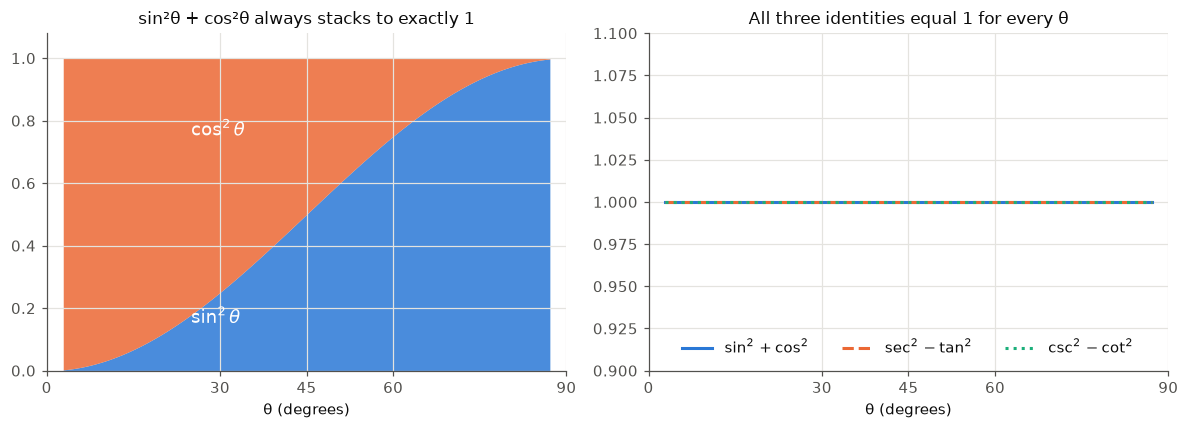

In [14]:
theta = np.linspace(0.05, np.pi/2 - 0.05, 400)     # acute angles, avoiding 0 and π/2
s, c = np.sin(theta), np.cos(theta)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.fill_between(np.rad2deg(theta), 0, s**2, color=BLUE, alpha=0.85, lw=0, label=r"$\sin^2\theta$")
ax.fill_between(np.rad2deg(theta), s**2, s**2 + c**2, color=ORANGE, alpha=0.85, lw=0, label=r"$\cos^2\theta$")
ax.set_xlim(0, 90); ax.set_ylim(0, 1.08); ax.set_xlabel("θ (degrees)")
ax.set_xticks([0, 30, 45, 60, 90])
ax.text(25, 0.15, r"$\sin^2\theta$", color="white", fontsize=12)
ax.text(25, 0.75, r"$\cos^2\theta$", color="white", fontsize=12)
ax.set_title("sin²θ + cos²θ always stacks to exactly 1", fontsize=11)

ax = axes[1]
ax.plot(np.rad2deg(theta), s**2 + c**2, color=BLUE, lw=2, label=r"$\sin^2+\cos^2$")
ax.plot(np.rad2deg(theta), 1/c**2 - (s/c)**2, color=ORANGE, lw=2, ls="--", label=r"$\sec^2-\tan^2$")
ax.plot(np.rad2deg(theta), 1/s**2 - (c/s)**2, color=AQUA, lw=2, ls=":", label=r"$\csc^2-\cot^2$")
ax.set_ylim(0.9, 1.1); ax.set_xlim(0, 90); ax.set_xticks([0, 30, 45, 60, 90]); ax.set_xlabel("θ (degrees)")
ax.legend(loc="lower center", ncol=3, frameon=False)
ax.set_title("All three identities equal 1 for every θ", fontsize=11)
plt.tight_layout(); plt.show()

---
## 10. Advanced Identities (useful for competitive exams)

These pairs have a curious property: **multiplying them gives the same result as adding (or subtracting) them.**

$$\boxed{\sec^2\theta\cdot\csc^2\theta = \sec^2\theta + \csc^2\theta}$$
$$\boxed{\tan^2\theta\cdot\sin^2\theta = \tan^2\theta - \sin^2\theta}$$
$$\boxed{\cot^2\theta\cdot\cos^2\theta = \cot^2\theta - \cos^2\theta}$$

> **Aside (puzzle from the lecture):** which numbers give the same answer whether you multiply or add them? For example $2\times 2 = 2+2 = 4$. In general $ab = a+b \iff b = \dfrac{a}{a-1}$, so there are infinitely many pairs, e.g. $(3, \tfrac32)$ and $(5, \tfrac54)$. The plot below shows the whole curve.

### Proof of $\sec^2\theta\cdot\csc^2\theta = \sec^2\theta + \csc^2\theta$ (done in class)
$$\text{LHS} = \frac{1}{\cos^2\theta}\cdot\frac{1}{\sin^2\theta} = \frac{1}{\sin^2\theta\cos^2\theta} = \frac{\sin^2\theta + \cos^2\theta}{\sin^2\theta\cos^2\theta}$$
(replacing $1$ by $\sin^2\theta + \cos^2\theta$)
$$= \frac{\sin^2\theta}{\sin^2\theta\cos^2\theta} + \frac{\cos^2\theta}{\sin^2\theta\cos^2\theta} = \frac{1}{\cos^2\theta} + \frac{1}{\sin^2\theta} = \sec^2\theta + \csc^2\theta = \text{RHS} \quad\blacksquare$$

### Proof of $\tan^2\theta\cdot\sin^2\theta = \tan^2\theta - \sin^2\theta$ *(homework)*
$$\text{RHS} = \frac{\sin^2\theta}{\cos^2\theta} - \sin^2\theta = \sin^2\theta\left(\frac{1 - \cos^2\theta}{\cos^2\theta}\right) = \sin^2\theta\cdot\frac{\sin^2\theta}{\cos^2\theta} = \sin^2\theta\tan^2\theta = \text{LHS} \quad\blacksquare$$

### Proof of $\cot^2\theta\cdot\cos^2\theta = \cot^2\theta - \cos^2\theta$ *(homework)*
$$\text{RHS} = \frac{\cos^2\theta}{\sin^2\theta} - \cos^2\theta = \cos^2\theta\left(\frac{1 - \sin^2\theta}{\sin^2\theta}\right) = \cos^2\theta\cdot\frac{\cos^2\theta}{\sin^2\theta} = \cos^2\theta\cot^2\theta = \text{LHS} \quad\blacksquare$$

max |LHS − RHS| = 1.42e-14   for sec²θ·cosec²θ  vs  sec²θ + cosec²θ
max |LHS − RHS| = 1.42e-14   for tan²θ·sin²θ  vs  tan²θ − sin²θ
max |LHS − RHS| = 7.11e-15   for cot²θ·cos²θ  vs  cot²θ − cos²θ


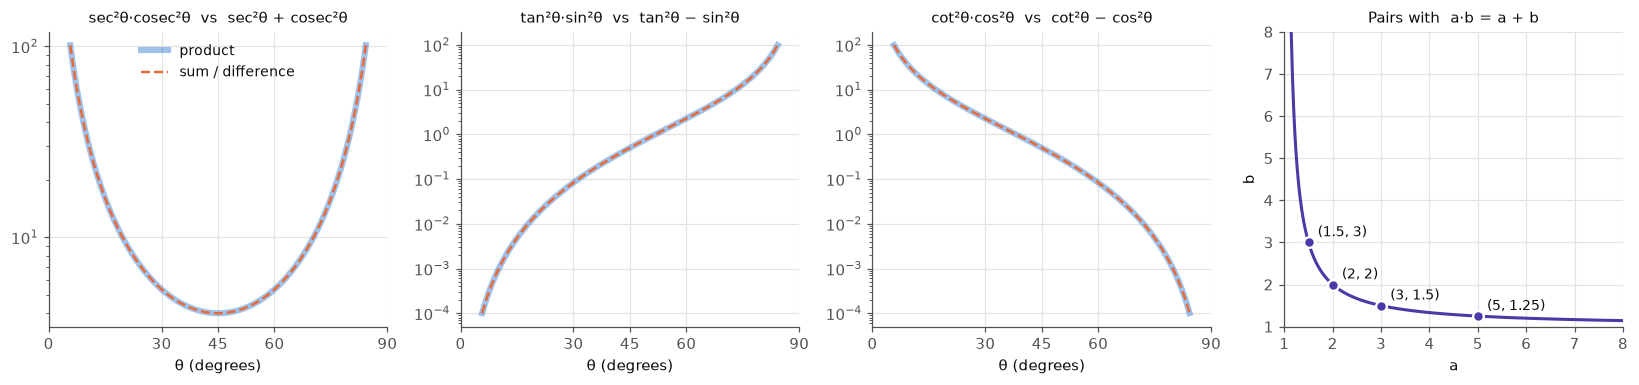

In [15]:
theta = np.linspace(0.1, np.pi/2 - 0.1, 400); deg = np.rad2deg(theta)
s, c, t = np.sin(theta), np.cos(theta), np.tan(theta)
checks = [
    ("sec²θ·cosec²θ  vs  sec²θ + cosec²θ", (1/c**2)*(1/s**2), 1/c**2 + 1/s**2),
    ("tan²θ·sin²θ  vs  tan²θ − sin²θ", t**2 * s**2, t**2 - s**2),
    ("cot²θ·cos²θ  vs  cot²θ − cos²θ", (1/t)**2 * c**2, (1/t)**2 - c**2),
]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (title, lhs, rhs) in zip(axes[:3], checks):
    ax.plot(deg, lhs, color=BLUE, lw=4, alpha=0.45, label="product")
    ax.plot(deg, rhs, color=ORANGE, lw=1.6, ls="--", label="sum / difference")
    ax.set_yscale("log"); ax.set_xlabel("θ (degrees)"); ax.set_xticks([0, 30, 45, 60, 90])
    ax.set_title(title, fontsize=10)
    print(f"max |LHS − RHS| = {np.max(np.abs(lhs - rhs)):.2e}   for {title}")
axes[0].legend(frameon=False, fontsize=9)

ax = axes[3]                                     # the puzzle: ab = a + b
a1 = np.linspace(1.1, 8, 300); ax.plot(a1, a1/(a1-1), color=VIOLET, lw=2)
for a_, b_ in [(2, 2), (3, 1.5), (1.5, 3), (5, 1.25)]:
    ax.plot(a_, b_, "o", color=VIOLET, ms=7, mec="white", mew=1.5)
    ax.annotate(f"({a_:g}, {b_:g})", (a_, b_), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlim(1, 8); ax.set_ylim(1, 8); ax.set_xlabel("a"); ax.set_ylabel("b")
ax.set_title("Pairs with  a·b = a + b", fontsize=10)
plt.tight_layout(); plt.show()

---
## 11. Summary / Cheat-sheet

| Concept | Key fact |
|---|---|
| Angle | $\theta = \ell / r$ (in radians); rotation from initial to terminal line |
| Sign | Anticlockwise is $+$, clockwise is $-$ |
| Range | $\theta \in (-\infty, \infty)$; $0^\circ$ and $360^\circ$ end in the same position |
| Units | $180^\circ = \pi$ rad; $1^\circ = \frac{\pi}{180}$ rad; $1$ rad $= \frac{180^\circ}{\pi} \approx 57.3^\circ$ |
| Default unit | No symbol means **radians** |
| Sub-units | $1^\circ = 60'$, $1' = 60''$, $1^\circ = 3600''$ |
| Revolution | $1$ rev $= 360^\circ = 2\pi$ |
| Arc formula | $\ell = r\theta$, with **θ in radians only** |
| Ratios | $\sin = P/H$, $\cos = B/H$, $\tan = P/B$, and their reciprocals |
| Why 6 | $^3P_2 = 6$ ordered pairs of 3 sides |
| Basic identities | $\sin^2+\cos^2=1$, $\sec^2-\tan^2=1$, $\csc^2-\cot^2=1$ (all from Pythagoras) |
| Advanced | $\sec^2\csc^2 = \sec^2+\csc^2$, $\tan^2\sin^2 = \tan^2-\sin^2$, $\cot^2\cos^2 = \cot^2-\cos^2$ |

### Practice
1. Convert $25^\circ 15'$ and $-47^\circ 30'$ to radians.
2. Convert $\dfrac{11\pi}{16}$ rad and $6$ rad to degrees, minutes and seconds.
3. Find the angle in radians subtended by an arc of 22 cm in a circle of radius 100 cm.
4. Prove all three advanced identities on your own without looking at the notes.

In [16]:
# Answers to the practice problems (check after attempting them yourself)
def rad_to_dms(rad):
    total_sec = round(np.rad2deg(rad) * 3600, 1)          # round first to avoid 44' 60"
    d, rem = divmod(total_sec, 3600); m, sec = divmod(rem, 60)
    return int(d), int(m), sec

print("1.", f"25°15' = {dms_to_rad(25, 15)[1]:.5f} rad (= 101π/720)", "|",
      f"-47°30' = {-dms_to_rad(47, 30)[1]:.5f} rad (= -19π/72)")
d, m, s = rad_to_dms(11*np.pi/16); print("2.", f"11π/16 = {d}° {m}' {s:.0f}\"", end=" | ")
d, m, s = rad_to_dms(6);           print(f"6 rad ≈ {d}° {m}' {s:.1f}\"")
print("3.", f"θ = 22/100 = {22/100} rad")

1. 25°15' = 0.44070 rad (= 101π/720) | -47°30' = -0.82903 rad (= -19π/72)
2. 11π/16 = 123° 45' 0" | 6 rad ≈ 343° 46' 28.8"
3. θ = 22/100 = 0.22 rad
